In [1]:
import gymnasium as gym
import numpy as np
from envs.register import register_envs
register_envs()

from explorers import EpsilonGreedy
from learners import Qlearning, QuantileRegression
from dist_run import *
from policy_util import *
from analysis import *
from matplotlib import pyplot as plt

def get_tau(N): return (np.arange(N) + 0.5) / N

params = Params(
    model_name="CliffSimple-v1",
    total_episodes=20_000,
    save_skip=10,
    n_runs=1,
    seed=123,
    
    lr_decay=2000,
    learning_rate=0.8,

    gamma=0.99,
    epsilon=0.1,
    huber_k=0.0,
    n_quantiles=256,
    
    action_size=None,
    state_size=None,
    map_size=None,
    
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = get_tau(params.n_quantiles)

env = gym.make(
    params.model_name,
    render_mode="rgb_array",
    # p_random=0.25
    # desc=None,
    # reward_schedule=(10, -100, -1),
    # success_rate=0.75,
)
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)

env.reset()
s_init = env.unwrapped.s

learner = QuantileRegression(params)
if isinstance(learner, Qlearning): params = params._replace(n_quantiles=1)
if params.learner_name is None:
    params = params._replace(learner_name=str(learner).split(".")[1].split(" ")[0])

In [19]:
# tables, qtables, params = load_experiment()
# V_q = qtables.max(-1)

In [25]:
import numpy as np
from collections import defaultdict

def monte_carlo_rollouts(env, state, policy, n_rollouts=1000, gamma=1.0):
    returns = []
    for _ in range(n_rollouts):
        env.reset()
        env.state = state  # set initial state
        total_return = 0
        discount = 1
        done = False
        
        while not done:
            action = policy[state]
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_return += discount * reward
            discount *= gamma
            state = next_state
            
        returns.append(total_return)
    return returns

def policy_iteration_mc(env, gamma=1.0, n_rollouts=1000):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Initialize random policy
    policy = np.random.choice(n_actions, size=n_states)
    empirical_returns = defaultdict(list)
    
    is_policy_stable = False
    
    while not is_policy_stable:
        # Policy evaluation (Monte Carlo)
        state_values = np.zeros(n_states)
        for s in range(n_states):
            returns = monte_carlo_rollouts(env, s, policy, n_rollouts=n_rollouts, gamma=gamma)
            empirical_returns[s] = returns
            state_values[s] = np.mean(returns)
        
        # Policy improvement
        is_policy_stable = True
        for s in range(n_states):
            action_returns = np.zeros(n_actions)
            for a in range(n_actions):
                # simulate taking action a first
                temp_policy = policy.copy()
                temp_policy[s] = a
                returns = monte_carlo_rollouts(env, s, temp_policy, n_rollouts=n_rollouts, gamma=gamma)
                action_returns[a] = np.mean(returns)
            
            best_action = np.argmax(action_returns)
            if best_action != policy[s]:
                is_policy_stable = False
                policy[s] = best_action
    
    return policy, empirical_returns

# Example usage with a discrete Gym environment
optimal_policy, empirical_returns = policy_iteration_mc(env, gamma=0.99, n_rollouts=1000)

print("Optimal Policy:", optimal_policy)
print("Example return distribution for state 0:", empirical_returns[0][:10])

KeyboardInterrupt: 

In [ ]:
pi_random = np.ones((params.state_size, params.action_size)) / params.action_size
for s in range(params.state_size):
    pos = np.unravel_index(s, params.map_size)
    if env.unwrapped._cliff[pos]: continue

    MonteCarlo(env, pi_random, params, s, rng, epsilon=0.1, total_episodes=1_000)

In [2]:
safe_policy = np.zeros((*params.map_size, params.action_size))
safe_policy[:] = np.eye(params.action_size)[0]
safe_policy[0] = np.eye(params.action_size)[1]
safe_policy[:,-1] = np.eye(params.action_size)[2]
safe_policy = safe_policy.reshape(params.state_size, params.action_size)

fast_policy = np.zeros((*params.map_size, params.action_size))
fast_policy[:] = np.eye(params.action_size)[0]
fast_policy[0:3] = np.eye(params.action_size)[1]
fast_policy[:,-1] = np.eye(params.action_size)[2]
fast_policy = fast_policy.reshape(params.state_size, params.action_size)

In [16]:
policy, V = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(params.epsilon, rng, policy=policy)

tables_run = run_env(env, learner, explorer, params)
tables = tables_run.mean(0)
qtables = tables.mean(-1)
V_q = qtables.max(-1)

q_init = tables[-1,s_init]

# save_experiment(tables, params)

Run 0/1 - Episodes: 100%|██████████| 20000/20000 [00:45<00:00, 444.23it/s]


In [17]:
returns = MonteCarlo(env, policy, params, s_init, rng, epsilon=0.1, total_episodes=20_000)

100%|██████████| 20000/20000 [00:06<00:00, 3037.56it/s]


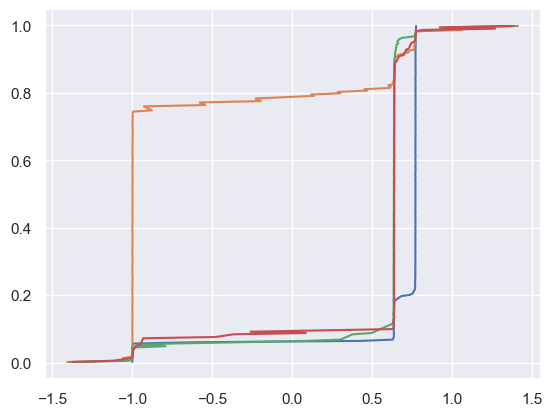

In [21]:
action_quants = q_init
arrow_directions = {0: "↑", 1: "→", 2: "↓", 3: "←"}
for a in range(params.action_size):
    plt.plot(action_quants[a], tau, label=arrow_directions[a])

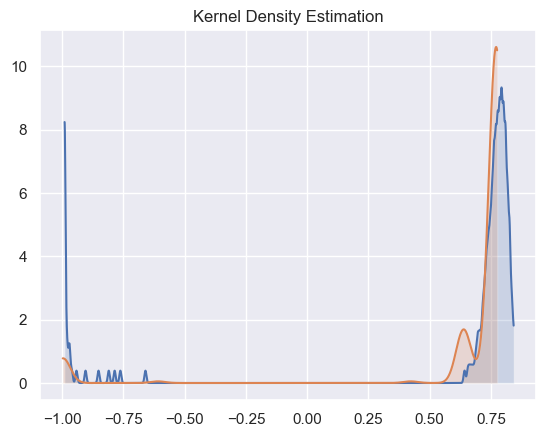

In [22]:
plot_returns(np.quantile(returns, tau), bandwidth=0.004)
plot_returns(q_init[0], bandwidth=0.03)
# plt.xlim(-20,0)

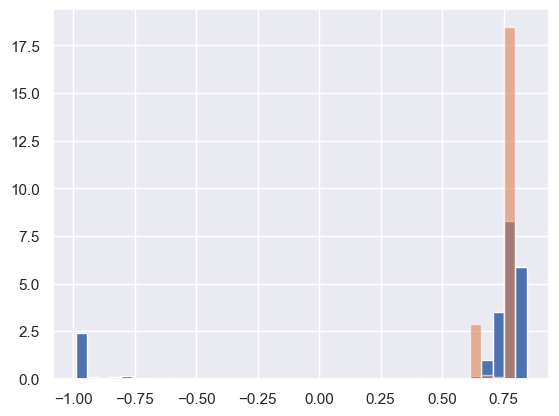

In [19]:
_, bins, _ = plt.hist(returns, bins=40, density=True)
# plt.hist(q_init[0], bins=bins, density=True, alpha=0.6);

ep = -1

state = 36
quant = tables[ep,state, qtables[ep,state].argmax()]

plt.hist(quant, bins=bins, density=True, alpha=0.6);

In [423]:
from display_qtables import display_qtables
display_qtables(qtables[::10], params)

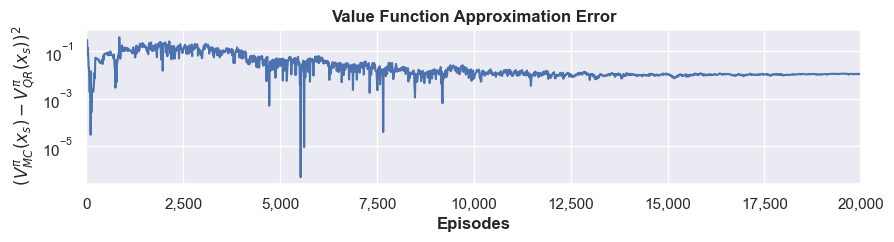

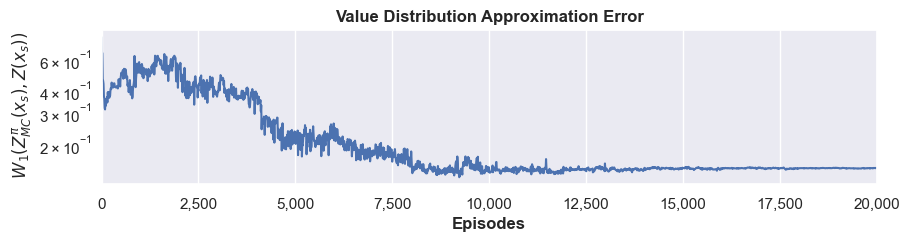

In [23]:
V_mc = returns.mean()
V_qr = qtables[:,s_init].max(1)

fig, ax = plot_value_approx((V_mc - V_qr)**2, params)
ax.set_ylabel(" $ (V_{MC}^{\pi}(x_s) - V_{QR}^{\pi}(x_s) )^2 $")
ax.set_xlabel("Episodes", fontweight="bold")
ax.set_title("Value Function Approximation Error", fontweight="bold")

Z_mc = np.quantile(np.sort(returns), tau)
Z_qr = tables[:, s_init].max(1)

fig, ax = plot_value_approx(abs(Z_qr - Z_mc).mean(1), params)